# Endogenous Reachability Collapse (ERC-D)

## A Minimal Dynamical Model of Loss of Recoverability Without Loss of State Space

Jaime Ojeda¹, ChatGPT (OpenAI)²  
¹ Independent researcher  
² AI-assisted modeling and analysis

---

This notebook reproduces the minimal simulations presented in the ERC-D model.

It demonstrates:
- differential recoverability under identical input,
- a sharp recoverability boundary,
- loss of return without removal of the baseline state,
- and robustness of the phenomenon to threshold, feedback strength, and input duration.

All results can be generated by running the notebook sequentially.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 11

In [ ]:
def make_input(t, t_start=2.0, t_end=6.0, amplitude=1.0):
    u = np.zeros_like(t)
    u[(t >= t_start) & (t <= t_end)] = amplitude
    return u

In [ ]:
def simulate_module(s, t, u, r=1.0, b=2.0, xc=0.5, K=1.0):
    dt = t[1] - t[0]
    x = np.zeros_like(t)

    for i in range(1, len(t)):
        nonlinear = b * x[i-1] * (x[i-1] - xc) * (1 - x[i-1] / K)
        dx = -r * x[i-1] + s * u[i-1] + nonlinear
        x[i] = x[i-1] + dt * dx

        if x[i] < 0:
            x[i] = 0
        if x[i] > 3.0:
            x[i] = 3.0

    return x

In [ ]:
t = np.linspace(0, 180, 4000)

def make_input(t, t_start=10.0, t_end=55.0, amplitude=1.0):
    u = np.zeros_like(t)
    u[(t >= t_start) & (t <= t_end)] = amplitude
    return u

u = make_input(t, t_start=10.0, t_end=55.0, amplitude=1.0)

In [ ]:
r_fixed = 0.42
b_fixed = 1.40
xc_fixed = 0.30
K_fixed = 2.0

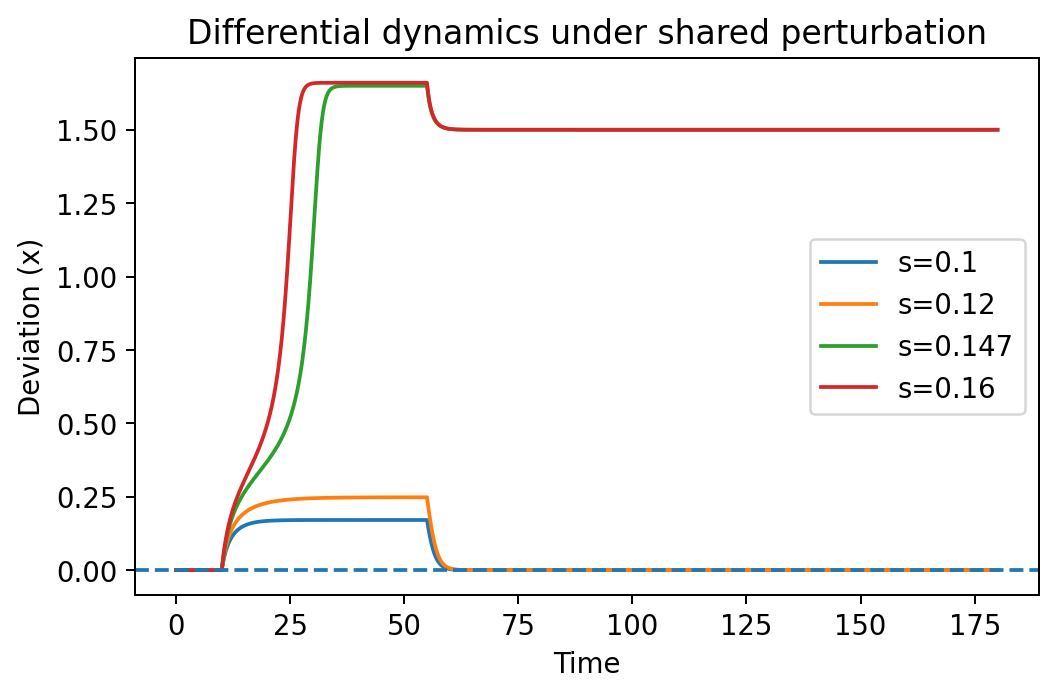

In [ ]:
s_values_demo = [0.10, 0.12, 0.147, 0.16]

plt.figure(figsize=(6,4), dpi=180)

for s in s_values_demo:
    x = simulate_module(s, t, u, r=r_fixed, b=b_fixed, xc=xc_fixed, K=K_fixed)
    plt.plot(t, x, label=f"s={s}")

plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Deviation (x)")
plt.title("Differential dynamics under shared perturbation")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics(x, t, high_threshold=0.8, recovery_threshold=0.1):
    high_occ = np.mean(x > high_threshold)
    tail_mean = np.mean(x[int(0.8 * len(x)):])
    recovered = x[-1] < recovery_threshold
    return high_occ, tail_mean, recovered

In [ ]:
s_scan = np.linspace(0.08, 0.20, 60)

recovered_fraction = []
tail_values = []

for s in s_scan:
    x = simulate_module(s, t, u, r=r_fixed, b=b_fixed, xc=xc_fixed, K=K_fixed)
    _, tail_mean, recovered = compute_metrics(x, t)
    recovered_fraction.append(int(recovered))
    tail_values.append(tail_mean)

In [ ]:
crossings = np.where(np.array(recovered_fraction) < 0.5)[0]

if len(crossings) == 0:
    print("No recoverability boundary found in current scan range.")
    s_crit = None
else:
    threshold_index = crossings[0]
    s_crit = s_scan[threshold_index]
    print("Critical sensitivity s* =", s_crit)

Critical sensitivity s* = 0.1328813559322034


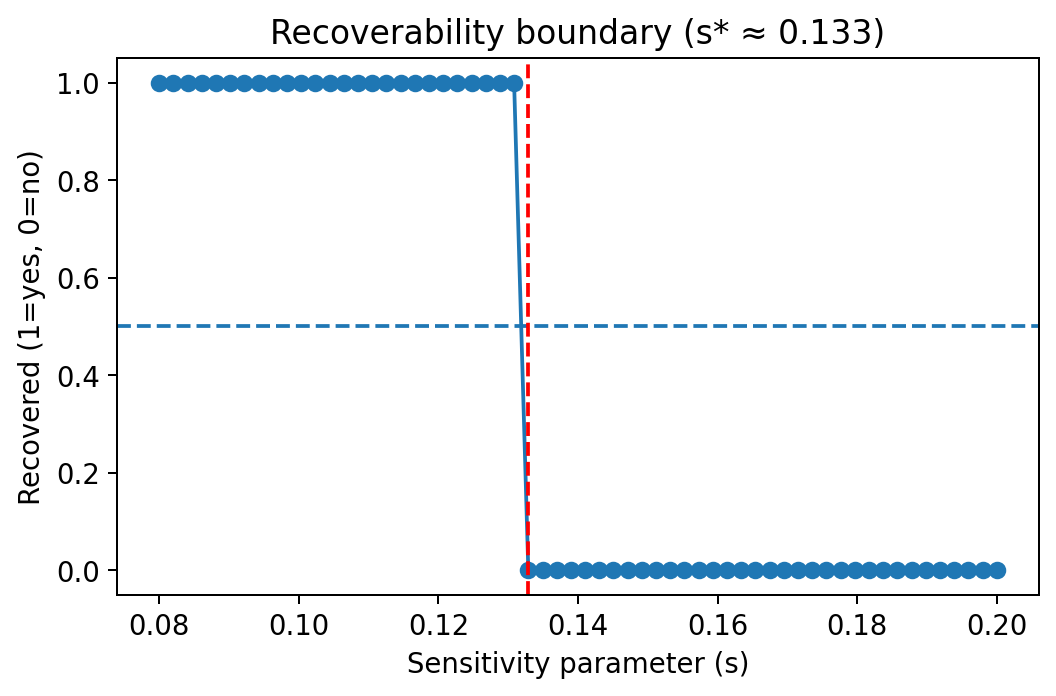

In [ ]:
plt.figure(figsize=(6,4), dpi=180)
plt.plot(s_scan, recovered_fraction, marker="o")
plt.axhline(0.5, linestyle="--")

if s_crit is not None:
    plt.axvline(s_crit, linestyle="--", color="red")
    plt.title(f"Recoverability boundary (s* ≈ {s_crit:.3f})")
else:
    plt.title("Recoverability boundary not found in current scan")

plt.xlabel("Sensitivity parameter (s)")
plt.ylabel("Recovered (1=yes, 0=no)")
plt.tight_layout()
plt.show()

## Robustness test 1 — Recovery threshold

We test whether the recoverability boundary depends strongly on the numerical threshold used to define return to baseline.

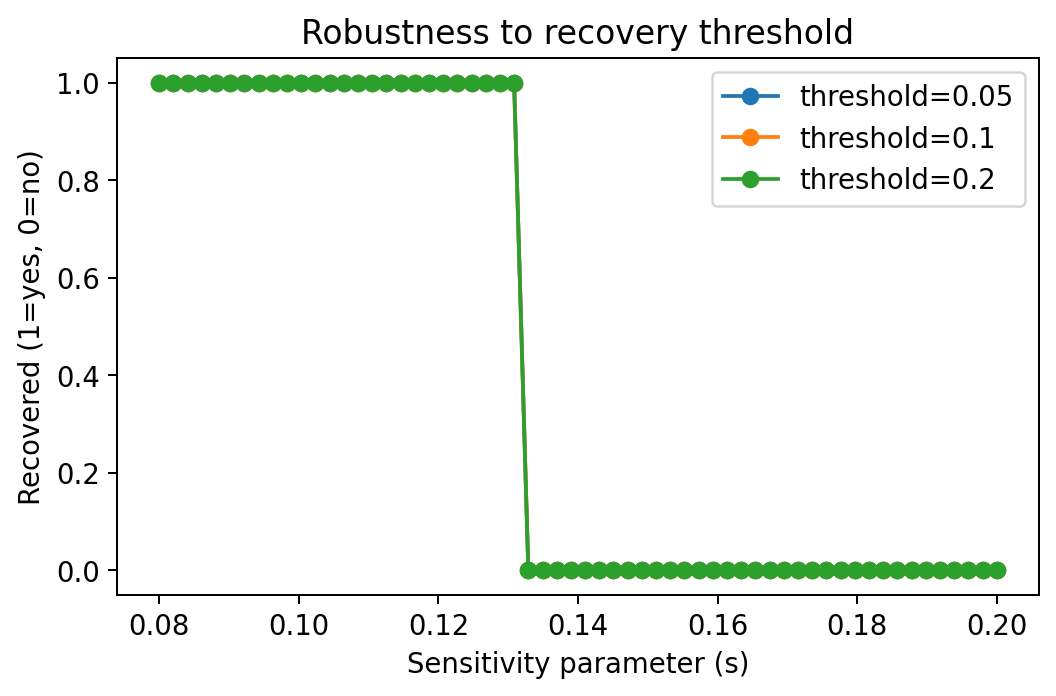

In [ ]:
thresholds = [0.05, 0.1, 0.2]

plt.figure(figsize=(6,4), dpi=180)

for thr in thresholds:
    rec_thr = []
    for s in s_scan:
        x = simulate_module(s, t, u, r=r_fixed, b=b_fixed, xc=xc_fixed, K=K_fixed)
        recovered = x[-1] < thr
        rec_thr.append(int(recovered))
    plt.plot(s_scan, rec_thr, marker="o", label=f"threshold={thr}")

plt.xlabel("Sensitivity parameter (s)")
plt.ylabel("Recovered (1=yes, 0=no)")
plt.title("Robustness to recovery threshold")
plt.legend()
plt.tight_layout()
plt.savefig("fig3_threshold_robustness.png", bbox_inches="tight")
plt.show()

## Robustness test 2 — Nonlinear feedback strength

We test whether the recoverability boundary persists across different values of the nonlinear feedback parameter b.

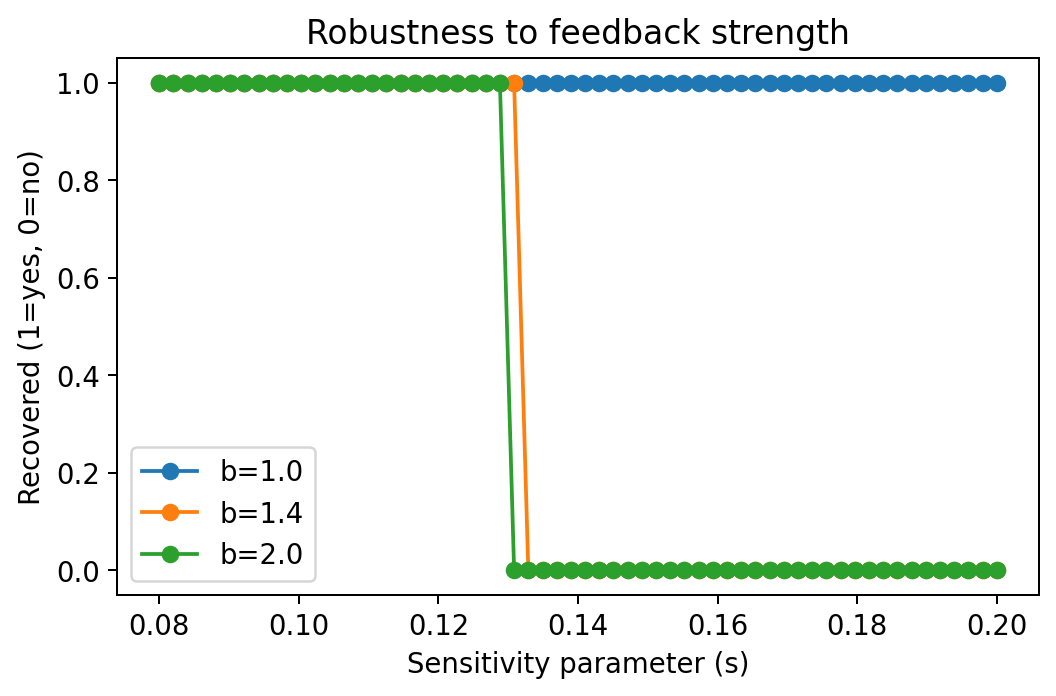

In [ ]:
b_values = [1.0, 1.4, 2.0]

plt.figure(figsize=(6,4), dpi=180)

for b_val in b_values:
    rec_b = []
    for s in s_scan:
        x = simulate_module(s, t, u, r=r_fixed, b=b_val, xc=xc_fixed, K=K_fixed)
        recovered = x[-1] < 0.1
        rec_b.append(int(recovered))
    plt.plot(s_scan, rec_b, marker="o", label=f"b={b_val}")

plt.xlabel("Sensitivity parameter (s)")
plt.ylabel("Recovered (1=yes, 0=no)")
plt.title("Robustness to feedback strength")
plt.legend()
plt.tight_layout()
plt.savefig("fig4_feedback_robustness.png", bbox_inches="tight")
plt.show()

## Robustness test 3 — Input duration

We test whether the recoverability boundary depends on the duration of the shared external perturbation.

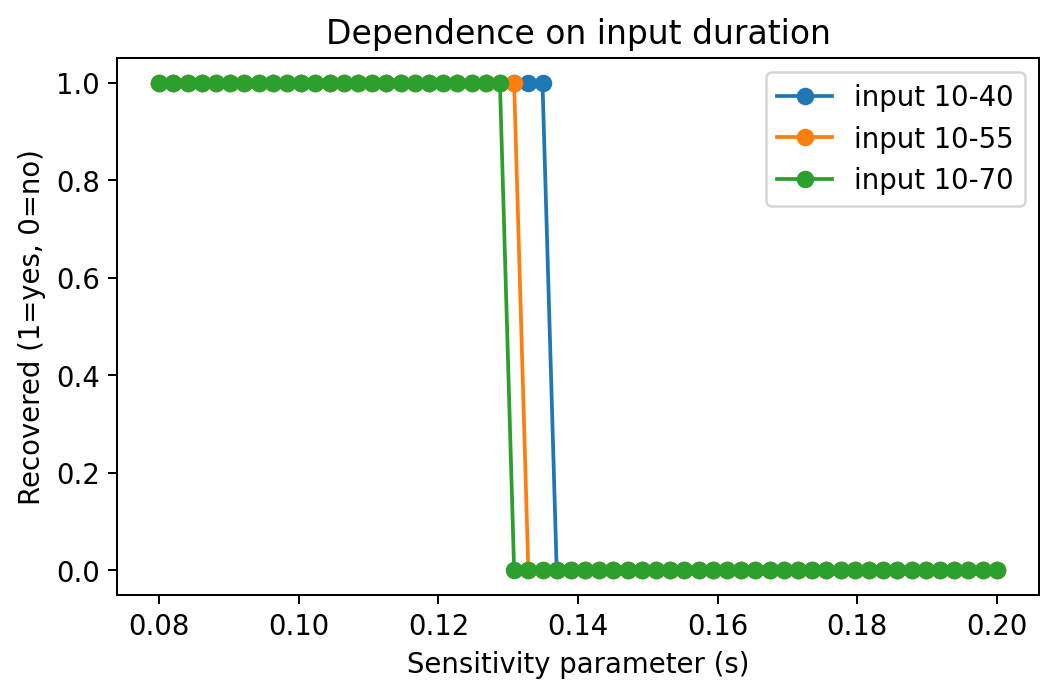

In [ ]:
durations = [(10, 40), (10, 55), (10, 70)]

plt.figure(figsize=(6,4), dpi=180)

for t_start, t_end in durations:
    u_var = make_input(t, t_start=t_start, t_end=t_end, amplitude=1.0)

    rec_dur = []
    for s in s_scan:
        x = simulate_module(s, t, u_var, r=r_fixed, b=b_fixed, xc=xc_fixed, K=K_fixed)
        recovered = x[-1] < 0.1
        rec_dur.append(int(recovered))

    plt.plot(s_scan, rec_dur, marker="o", label=f"input {t_start}-{t_end}")

plt.xlabel("Sensitivity parameter (s)")
plt.ylabel("Recovered (1=yes, 0=no)")
plt.title("Dependence on input duration")
plt.legend()
plt.tight_layout()
plt.savefig("fig5_input_duration_dependence.png", bbox_inches="tight")
plt.show()

## Negative control — No nonlinear feedback

We test whether the recoverability boundary persists when the nonlinear feedback term is removed.

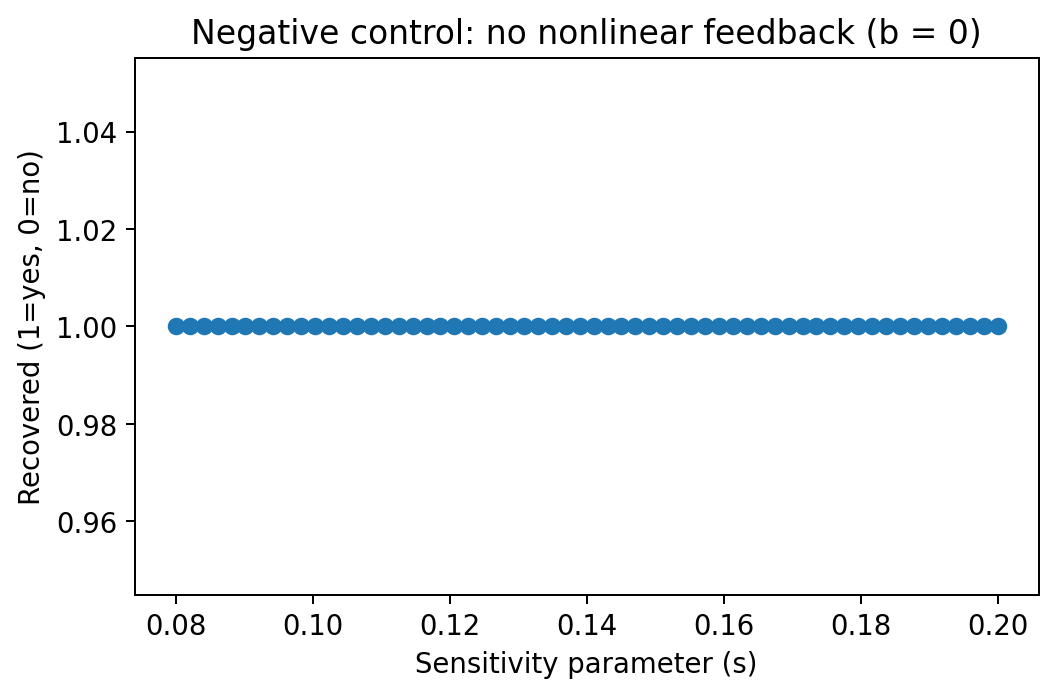

In [ ]:
rec_linear = []

for s in s_scan:
    x = simulate_module(s, t, u, r=r_fixed, b=0.0, xc=xc_fixed, K=K_fixed)
    recovered = x[-1] < 0.1
    rec_linear.append(int(recovered))

plt.figure(figsize=(6,4), dpi=180)
plt.plot(s_scan, rec_linear, marker="o")
plt.xlabel("Sensitivity parameter (s)")
plt.ylabel("Recovered (1=yes, 0=no)")
plt.title("Negative control: no nonlinear feedback (b = 0)")
plt.tight_layout()
plt.savefig("fig6_negative_control_linear.png", bbox_inches="tight")
plt.show()

## Continuous metric — Tail persistence

We visualize the mean late-state deviation as a continuous measure of persistence across the same parameter sweep.

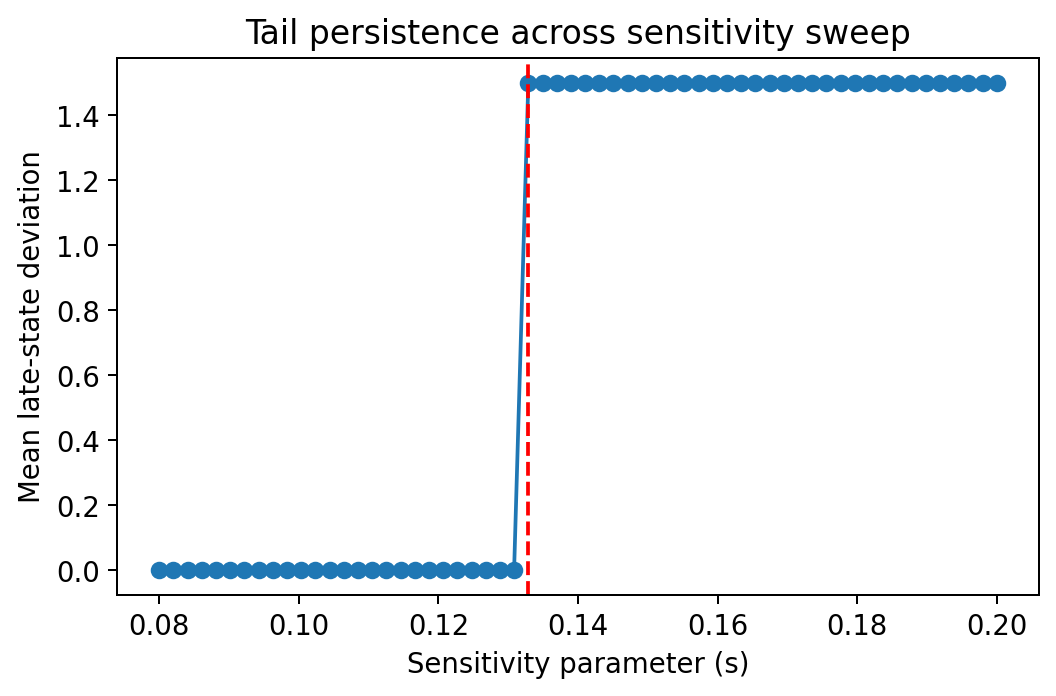

In [ ]:
tail_values = []

for s in s_scan:
    x = simulate_module(s, t, u, r=r_fixed, b=b_fixed, xc=xc_fixed, K=K_fixed)
    tail_mean = np.mean(x[int(0.8 * len(x)):])
    tail_values.append(tail_mean)

plt.figure(figsize=(6,4), dpi=180)
plt.plot(s_scan, tail_values, marker="o")
if s_crit is not None:
    plt.axvline(s_crit, linestyle="--", color="red")

plt.xlabel("Sensitivity parameter (s)")
plt.ylabel("Mean late-state deviation")
plt.title("Tail persistence across sensitivity sweep")
plt.tight_layout()
plt.savefig("fig7_tail_persistence.png", bbox_inches="tight")
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [13]:
# Parameters
omega = 1.5
b = 1.20
a0 = 0.75
alpha = 0.55
eps = 0.03
a_min = 0.05

def a_of_c(c):
    return max(a_min, a0 - alpha * c)

def rhs_full(t, z):
    x, y, c = z
    r2 = x*x + y*y
    a = a_of_c(c)
    g = -((r2 - a*a) * (r2 - b*b))
    dx = g*x - omega*y
    dy = g*y + omega*x
    dc = eps * (r2 / (1.0 + r2) - c)
    return [dx, dy, dc]

In [14]:
def simulate_full_fast(z0, Tfast=120, npts=1200):
    t_eval_fast = np.linspace(0, Tfast, npts)
    sol = solve_ivp(
        rhs_full,
        [0, Tfast],
        z0,
        t_eval=t_eval_fast,
        rtol=1e-6,
        atol=1e-8
    )
    x, y, c = sol.y
    r = np.sqrt(x*x + y*y)
    return sol.t, x, y, r, c

In [15]:
def compute_signals(t, r, c, eps0=1e-6):
    a_t = np.array([a_of_c(ci) for ci in c])
    S_margin = a_t - r
    S_norm = S_margin / (a_t + eps0)
    S_rate = np.gradient(S_margin, t)
    return a_t, S_margin, S_norm, S_rate

In [16]:
selected_r0 = [0.40, 0.68, 0.82]
signal_results = {}

for r0 in selected_r0:
    z0 = [r0, 0.0, 0.0]
    t, x, y, r, c = simulate_full_fast(z0)
    a_t, S_margin, S_norm, S_rate = compute_signals(t, r, c)

    signal_results[r0] = {
        "t": t,
        "x": x,
        "y": y,
        "r": r,
        "c": c,
        "a_t": a_t,
        "S_margin": S_margin,
        "S_norm": S_norm,
        "S_rate": S_rate,
    }

print("Signals ready.")

Signals ready.


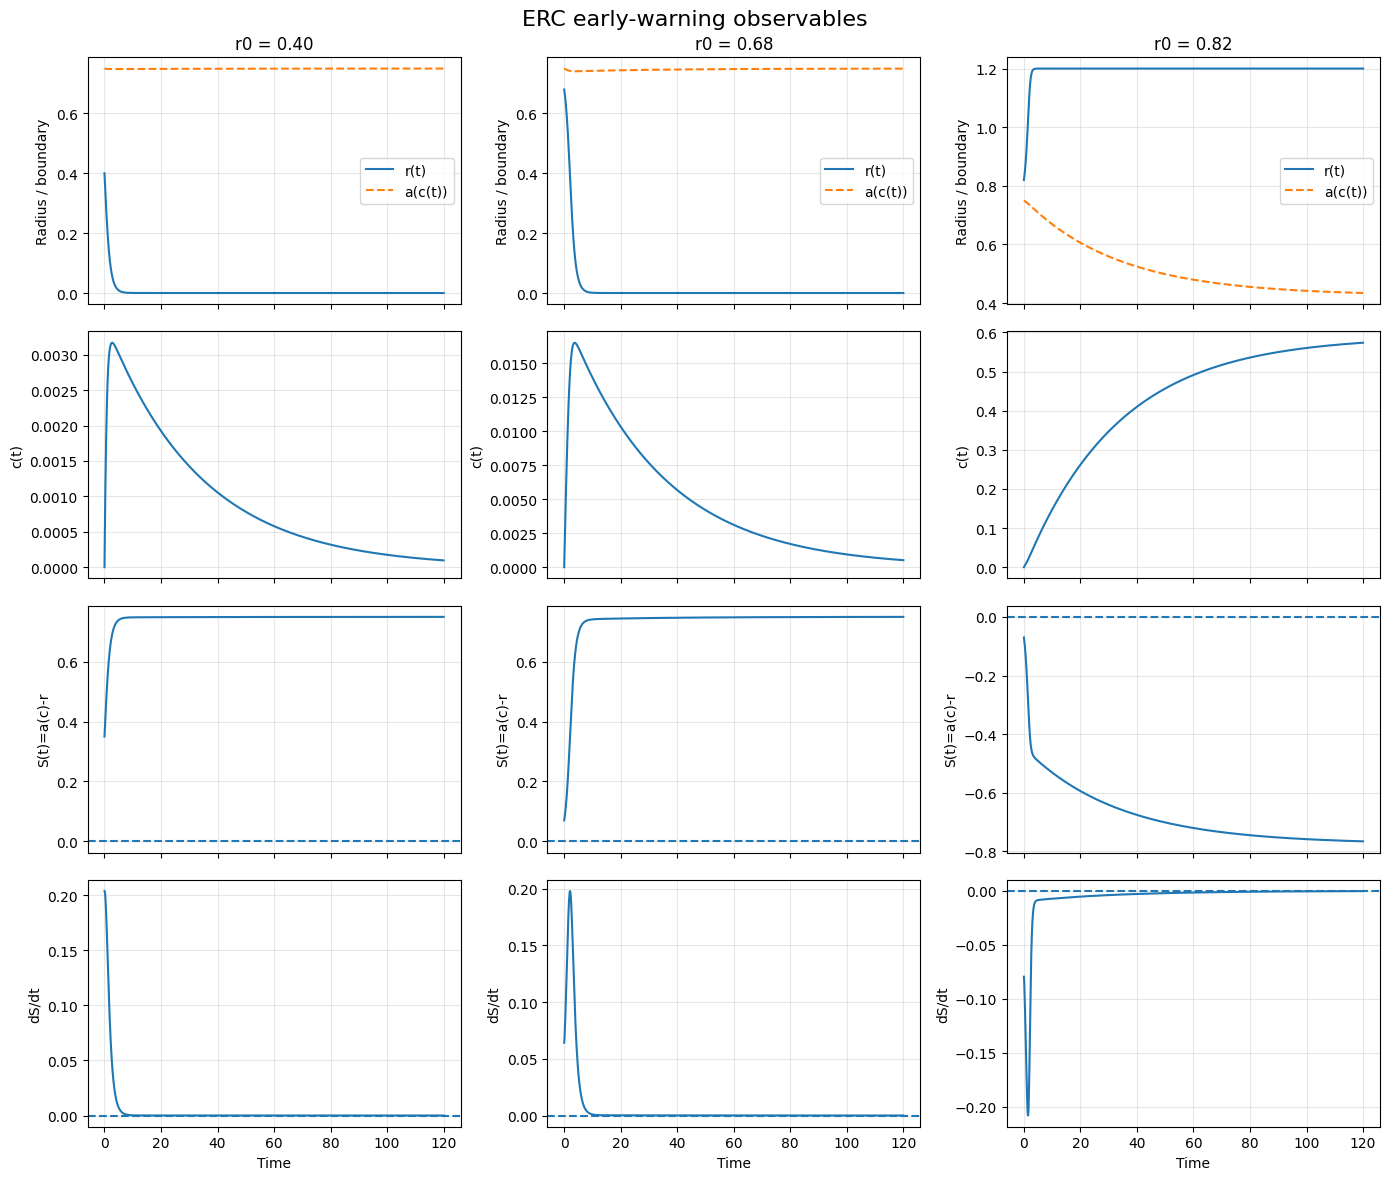

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharex='col')

for col, r0 in enumerate(selected_r0):
    t = signal_results[r0]["t"]
    r = signal_results[r0]["r"]
    c = signal_results[r0]["c"]
    a_t = signal_results[r0]["a_t"]
    S_margin = signal_results[r0]["S_margin"]
    S_norm = signal_results[r0]["S_norm"]
    S_rate = signal_results[r0]["S_rate"]

    # Row 1: radius and moving boundary
    axes[0, col].plot(t, r, label="r(t)")
    axes[0, col].plot(t, a_t, "--", label="a(c(t))")
    axes[0, col].set_title(f"r0 = {r0:.2f}")
    axes[0, col].set_ylabel("Radius / boundary")
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].legend()

    # Row 2: internal constraint
    axes[1, col].plot(t, c)
    axes[1, col].set_ylabel("c(t)")
    axes[1, col].grid(True, alpha=0.3)

    # Row 3: dynamic safety margin
    axes[2, col].plot(t, S_margin)
    axes[2, col].axhline(0, linestyle="--")
    axes[2, col].set_ylabel("S(t)=a(c)-r")
    axes[2, col].grid(True, alpha=0.3)

    # Row 4: rate of margin change
    axes[3, col].plot(t, S_rate)
    axes[3, col].axhline(0, linestyle="--")
    axes[3, col].set_ylabel("dS/dt")
    axes[3, col].set_xlabel("Time")
    axes[3, col].grid(True, alpha=0.3)

plt.suptitle("ERC early-warning observables", fontsize=16)
plt.tight_layout()
plt.show()

## Scope note

The recoverability boundary shown here arises within a specific parameter regime in which nonlinear feedback produces bistable-like dynamics. The boundary is therefore not universal across all parameter choices, but a property of this minimal regime.

## Summary

This notebook reproduces the main results of the ERC-D model:

- differential recovery under identical input,
- a sharp recoverability boundary at a critical sensitivity,
- persistence in a high-deviation state without removal of the baseline state,
- robustness to recovery threshold choice,
- dependence on feedback strength and input duration,
- and disappearance of the boundary in the absence of nonlinear feedback.

Together, these results are consistent with loss of dynamic accessibility rather than structural loss.

In [ ]:
model_parameters = {
    "r_fixed": r_fixed,
    "b_fixed": b_fixed,
    "xc_fixed": xc_fixed,
    "K_fixed": K_fixed,
    "s_crit": s_crit
}

model_parameters

{'r_fixed': 0.42,
 'b_fixed': 1.4,
 'xc_fixed': 0.3,
 'K_fixed': 2.0,
 's_crit': np.float64(0.1328813559322034)}

In [ ]:
pd.Series(model_parameters).to_csv("ercd_model_parameters.csv")